# Macro Regime Data Preparation

## Objective
Prepare and visualize the four macro time series that will be used for **economic regime detection** 

### Steps
1. **Combine** the two Federal Funds Rate series (single-target era 1986–2008 + target-range era 2008–present) into one continuous `fedrate_all.csv`
2. **Normalize** all four series to [0, 1] via min-max scaling (same method as `process_data.ipynb`); CPI requires YoY% calculation first
3. **Plot** all four normalized series on the same chart

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── GitHub raw data URLs (no local files needed — runs in Colab/Kaggle/etc.) ──
_BASE         = "https://raw.githubusercontent.com/echochoho1010/forecasting_fed_rate/master/data"
URL_DFEDTAR   = f"{_BASE}/Federal%20Funds%20Target%20Rate.csv"
URL_DFEDTARU  = f"{_BASE}/Federal%20Funds%20Target%20Range%20Upper%20Limit.csv"
URL_UNRATE    = f"{_BASE}/Unemployment%20Rate%20UNRATE%20all.csv"
URL_WTI       = f"{_BASE}/WTI%20Crude%20Oil%20Prices%20all.csv"
URL_CPI       = f"{_BASE}/CPI%20All%20Urban%20Consumers%20all.csv"
URL_FEDRATE   = f"{_BASE}/fedrate_all.csv"

print("GitHub raw URLs configured.")
print(f"  Base : {_BASE}")


---
## Step 1 — Combine Federal Funds Rate Series

The Fed used a **single target rate** (`DFEDTAR`) from 1986 through 15 Dec 2008.  
On 16 Dec 2008 it switched to a **target range**; we use the upper bound (`DFEDTARU`) from that date forward.

The two series stitch together cleanly with no overlap.

In [ ]:
# ── Load raw series from GitHub ───────────────────────────────────────────────
df_tar = pd.read_csv(URL_DFEDTAR)
df_tar['observation_date'] = pd.to_datetime(df_tar['observation_date'])
df_tar['DFEDTAR'] = pd.to_numeric(df_tar['DFEDTAR'], errors='coerce')
df_tar = df_tar.dropna().sort_values('observation_date').reset_index(drop=True)

df_rng = pd.read_csv(URL_DFEDTARU)
df_rng['observation_date'] = pd.to_datetime(df_rng['observation_date'])
df_rng['DFEDTARU'] = pd.to_numeric(df_rng['DFEDTARU'], errors='coerce')
df_rng = df_rng.dropna().sort_values('observation_date').reset_index(drop=True)

print(f'DFEDTAR  (single target) : {df_tar["observation_date"].min().date()} → {df_tar["observation_date"].max().date()}  ({len(df_tar):,} rows)')
print(f'DFEDTARU (range upper)   : {df_rng["observation_date"].min().date()} → {df_rng["observation_date"].max().date()}  ({len(df_rng):,} rows)')


In [59]:
# ── Stitch: DFEDTAR up to (but not including) 2008-12-16, then DFEDTARU ───────
SWITCH_DATE = pd.Timestamp('2008-12-16')

pre  = df_tar[df_tar['observation_date'] < SWITCH_DATE][['observation_date', 'DFEDTAR']].rename(columns={'DFEDTAR': 'fed_rate'})
post = df_rng[['observation_date', 'DFEDTARU']].rename(columns={'DFEDTARU': 'fed_rate'})

df_fedrate = (
    pd.concat([pre, post], ignore_index=True)
    .sort_values('observation_date')
    .drop_duplicates('observation_date')   # safety guard
    .reset_index(drop=True)
)

print(f'Combined fed_rate series: {df_fedrate["observation_date"].min().date()} → {df_fedrate["observation_date"].max().date()}  ({len(df_fedrate):,} rows)')
print(f'Value range: {df_fedrate["fed_rate"].min():.2f}% – {df_fedrate["fed_rate"].max():.2f}%')

# Quick sanity check at the stitch point
mask = (df_fedrate['observation_date'] >= '2008-12-13') & (df_fedrate['observation_date'] <= '2008-12-18')
print('\nStitch window:')
print(df_fedrate[mask].to_string(index=False))

Combined fed_rate series: 1986-01-01 → 2026-02-27  (14,668 rows)
Value range: 0.25% – 9.81%

Stitch window:
observation_date  fed_rate
      2008-12-13      1.00
      2008-12-14      1.00
      2008-12-15      1.00
      2008-12-16      0.25
      2008-12-17      0.25
      2008-12-18      0.25


In [ ]:
# ── Optionally save fedrate_all.csv locally ───────────────────────────────────
# The file is already hosted on GitHub (URL_FEDRATE), so saving is only
# needed if you want a local copy or are running on a machine with write access.
try:
    import os
    _save_path = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                               '..', 'data', 'fedrate_all.csv')
    _save_path = os.path.normpath(_save_path)
    df_fedrate.to_csv(_save_path, index=False)
    print(f'Saved locally  → {_save_path}')
except Exception:
    print('Local save skipped (path not writable — using in-memory DataFrame).')

print(f'Remote copy    → {URL_FEDRATE}')

# Quick preview
display(df_fedrate.head(3))
display(df_fedrate.tail(3))


---
## Step 2 — Load, Process & Normalize All Four Series

| Series | Source | Frequency | Pre-processing |
|---|---|---|---|
| Fed Funds Rate | `fedrate_all.csv` | Daily | — |
| Unemployment Rate | `Unemployment Rate UNRATE all.csv` | Monthly | — |
| WTI Crude Oil | `WTI Crude Oil Prices all.csv` | Daily (trading days) | — |
| CPI | `CPI All Urban Consumers all.csv` | Monthly | **YoY% first**, then normalize |

Normalization: **min-max scaling** → $x_{norm} = (x - x_{min}) / (x_{max} - x_{min})$

In [61]:
def minmax(series):
    lo, hi = series.min(), series.max()
    return (series - lo) / (hi - lo)


# ── 2a. Fed Funds Rate (already loaded above) ─────────────────────────────────
df_fedrate['fed_rate_norm'] = minmax(df_fedrate['fed_rate'])

print('Fed Funds Rate')
print(f'  Raw   : min={df_fedrate["fed_rate"].min():.2f}%  max={df_fedrate["fed_rate"].max():.2f}%')
print(f'  Norm  : min={df_fedrate["fed_rate_norm"].min():.4f}  max={df_fedrate["fed_rate_norm"].max():.4f}')
print(f'  Range : {df_fedrate["observation_date"].min().date()} → {df_fedrate["observation_date"].max().date()}')

Fed Funds Rate
  Raw   : min=0.25%  max=9.81%
  Norm  : min=0.0000  max=1.0000
  Range : 1986-01-01 → 2026-02-27


In [ ]:
# ── 2b. Unemployment Rate ─────────────────────────────────────────────────────
df_unrate = pd.read_csv(URL_UNRATE)
df_unrate['observation_date'] = pd.to_datetime(df_unrate['observation_date'])
df_unrate['UNRATE'] = pd.to_numeric(df_unrate['UNRATE'], errors='coerce')
df_unrate = df_unrate.dropna().sort_values('observation_date').reset_index(drop=True)

df_unrate['UNRATE_norm'] = minmax(df_unrate['UNRATE'])

print('Unemployment Rate (UNRATE)')
print(f'  Raw   : min={df_unrate["UNRATE"].min():.1f}%  max={df_unrate["UNRATE"].max():.1f}%')
print(f'  Norm  : min={df_unrate["UNRATE_norm"].min():.4f}  max={df_unrate["UNRATE_norm"].max():.4f}')
print(f'  Range : {df_unrate["observation_date"].min().date()} → {df_unrate["observation_date"].max().date()}  (monthly)')


In [ ]:
# ── 2c. WTI Crude Oil ─────────────────────────────────────────────────────────
df_wti = pd.read_csv(URL_WTI)
df_wti['observation_date'] = pd.to_datetime(df_wti['observation_date'])
df_wti['DCOILWTICO'] = pd.to_numeric(df_wti['DCOILWTICO'], errors='coerce')
df_wti = df_wti.dropna().sort_values('observation_date').reset_index(drop=True)

df_wti['WTI_norm'] = minmax(df_wti['DCOILWTICO'])

print('WTI Crude Oil')
print(f'  Raw   : min=${df_wti["DCOILWTICO"].min():.2f}  max=${df_wti["DCOILWTICO"].max():.2f}  (USD/barrel)')
print(f'  Norm  : min={df_wti["WTI_norm"].min():.4f}  max={df_wti["WTI_norm"].max():.4f}')
print(f'  Range : {df_wti["observation_date"].min().date()} → {df_wti["observation_date"].max().date()}  (daily, trading days)')


In [ ]:
# ── 2d. CPI — YoY% first, then normalize ─────────────────────────────────────
df_cpi = pd.read_csv(URL_CPI)
df_cpi['observation_date'] = pd.to_datetime(df_cpi['observation_date'])
df_cpi['CPIAUCSL'] = pd.to_numeric(df_cpi['CPIAUCSL'], errors='coerce')
df_cpi = df_cpi.dropna().sort_values('observation_date').reset_index(drop=True)

# YoY% = (C_t / C_{t-12} − 1) × 100
df_cpi['CPI_YoY'] = (df_cpi['CPIAUCSL'] / df_cpi['CPIAUCSL'].shift(12) - 1) * 100
df_cpi = df_cpi.dropna(subset=['CPI_YoY']).reset_index(drop=True)

df_cpi['CPI_YoY_norm'] = minmax(df_cpi['CPI_YoY'])

print('CPI (All Urban Consumers)')
print(f'  YoY%  : min={df_cpi["CPI_YoY"].min():.2f}%  max={df_cpi["CPI_YoY"].max():.2f}%')
print(f'  Norm  : min={df_cpi["CPI_YoY_norm"].min():.4f}  max={df_cpi["CPI_YoY_norm"].max():.4f}')
print(f'  Range : {df_cpi["observation_date"].min().date()} → {df_cpi["observation_date"].max().date()}  (monthly, after 12-month shift)')


---
## Step 3 — Combined Plot

Monthly series (UNRATE, CPI) are **forward-filled to daily** so all four can share a single time axis.

In [65]:
# ── Build a common daily calendar spanning the overlap of all four series ──────
date_start = max(
    df_fedrate['observation_date'].min(),
    df_unrate['observation_date'].min(),
    df_wti['observation_date'].min(),
    df_cpi['observation_date'].min(),
)
date_end = min(
    df_fedrate['observation_date'].max(),
    df_unrate['observation_date'].max(),
    df_wti['observation_date'].max(),
    df_cpi['observation_date'].max(),
)
print(f'Common date range: {date_start.date()} → {date_end.date()}')

daily_idx = pd.date_range(date_start, date_end, freq='D')
df_daily  = pd.DataFrame({'observation_date': daily_idx})

# Merge each series using asof (forward-fill for monthly data)
def merge_asof(df_daily, df_src, date_col, val_col, out_col):
    src = df_src[[date_col, val_col]].sort_values(date_col)
    merged = pd.merge_asof(df_daily, src, left_on='observation_date',
                            right_on=date_col, direction='backward')
    merged = merged.rename(columns={val_col: out_col})
    if date_col != 'observation_date':
        merged = merged.drop(columns=[date_col], errors='ignore')
    return merged

df_daily = merge_asof(df_daily, df_fedrate, 'observation_date', 'fed_rate_norm',  'fed_rate_norm')
df_daily = merge_asof(df_daily, df_unrate,  'observation_date', 'UNRATE_norm',    'UNRATE_norm')
df_daily = merge_asof(df_daily, df_wti,     'observation_date', 'WTI_norm',       'WTI_norm')
df_daily = merge_asof(df_daily, df_cpi,     'observation_date', 'CPI_YoY_norm',   'CPI_YoY_norm')

df_daily = df_daily.dropna()
print(f'Daily aligned frame: {len(df_daily):,} rows, {df_daily.shape[1]} columns')
print(f'Final date range   : {df_daily["observation_date"].min().date()} → {df_daily["observation_date"].max().date()}')
df_daily.head(3)

Common date range: 1987-01-01 → 2026-01-01
Daily aligned frame: 14,246 rows, 5 columns
Final date range   : 1987-01-01 → 2026-01-01


,observation_date,fed_rate_norm,UNRATE_norm,WTI_norm,CPI_YoY_norm
0,1987-01-01,0.588235,0.280702,0.301223,0.303858
1,1987-01-02,0.588235,0.280702,0.302320,0.303858
2,1987-01-03,0.588235,0.280702,0.302320,0.303858


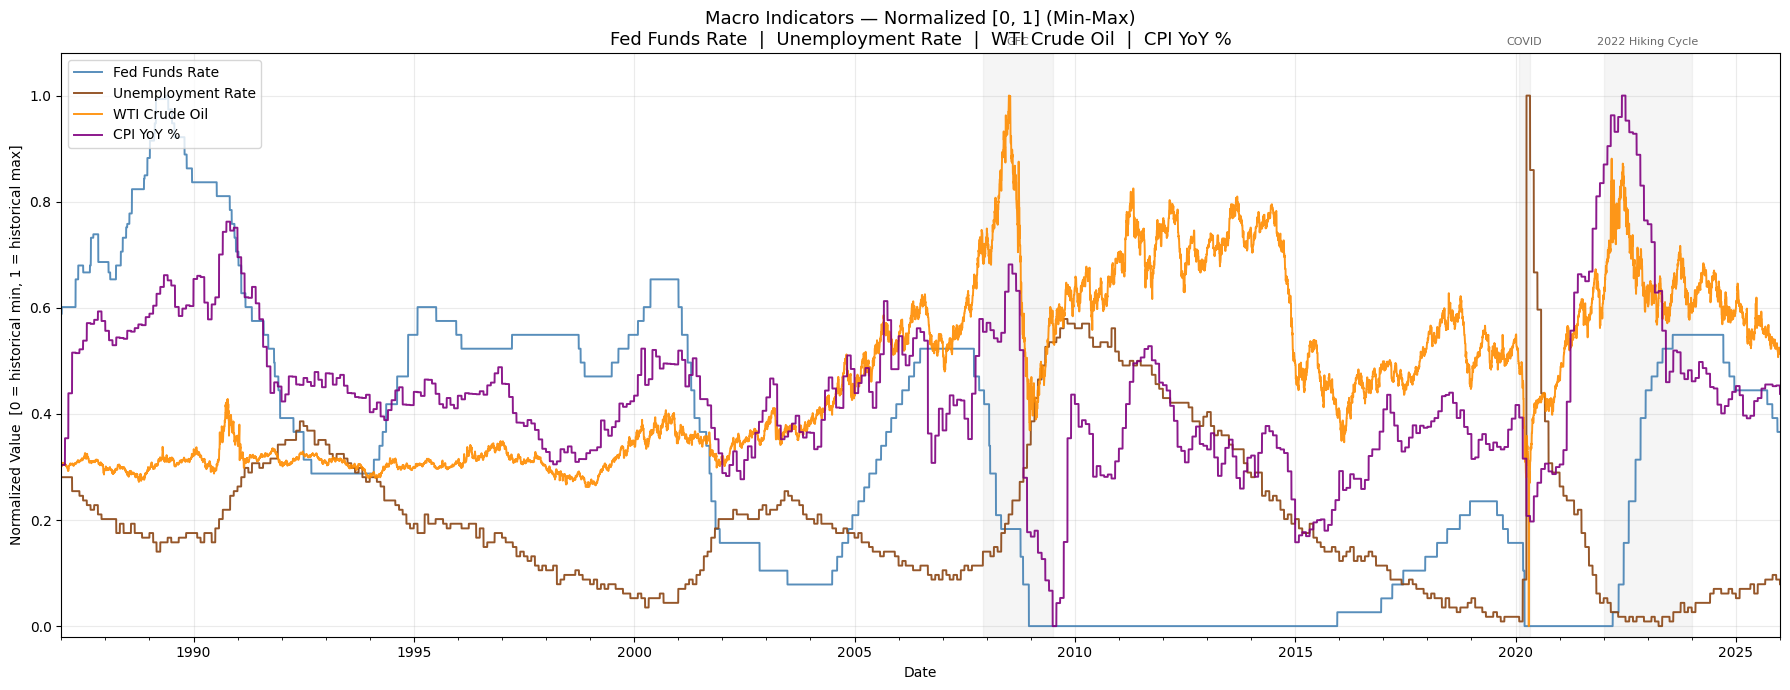

In [66]:
# ── Combined normalized plot ───────────────────────────────────────────────────
SERIES = [
    ('fed_rate_norm', 'steelblue',  'Fed Funds Rate'),
    ('UNRATE_norm',   '#8B4513',    'Unemployment Rate'),
    ('WTI_norm',      'darkorange', 'WTI Crude Oil'),
    ('CPI_YoY_norm',  'purple',     'CPI YoY %'),
]

fig, ax = plt.subplots(figsize=(18, 7))

for col, color, label in SERIES:
    ax.plot(df_daily['observation_date'], df_daily[col],
            color=color, linewidth=1.4, label=label, alpha=0.9)

# Shade the 2008-09 recession and 2020 covid dip for context
recessions = [
    ('2007-12-01', '2009-06-30', 'GFC'),
    ('2020-02-01', '2020-04-30', 'COVID'),
    ('2022-01-01', '2023-12-31', '2022 Hiking Cycle'),
]
for start, end, lbl in recessions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.08, color='grey')
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, 1.01, lbl, ha='center', va='bottom', fontsize=8,
            color='dimgrey', transform=ax.get_xaxis_transform())

ax.set_xlim(df_daily['observation_date'].min(), df_daily['observation_date'].max())
ax.set_ylim(-0.02, 1.08)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.tick_params(axis='x', which='major', labelsize=10)

ax.set_title(
    'Macro Indicators — Normalized [0, 1] (Min-Max)\n'
    'Fed Funds Rate  |  Unemployment Rate  |  WTI Crude Oil  |  CPI YoY %',
    fontsize=13
)
ax.set_ylabel('Normalized Value  [0 = historical min, 1 = historical max]')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

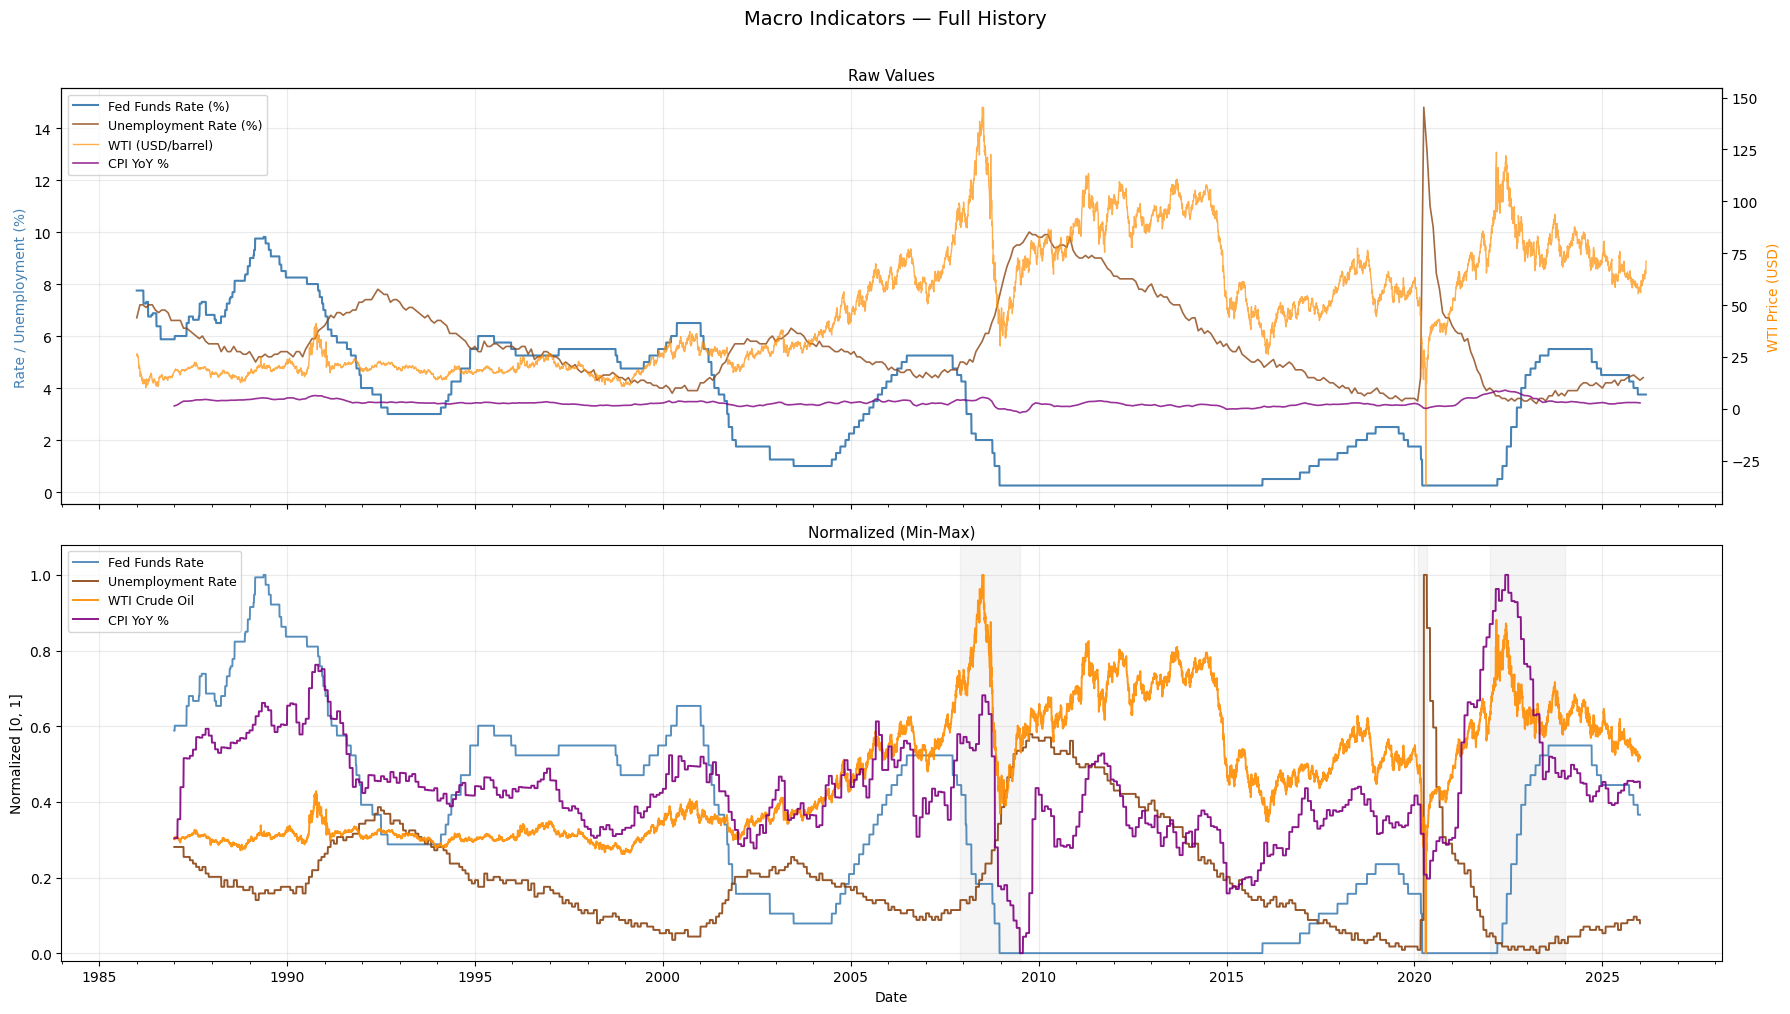

In [67]:
# ── Dual-panel: raw values (top) + normalized (bottom) ────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# ── Top: raw values on individual y-axes ──────────────────────────────────────
ax1b = ax1.twinx()

l1, = ax1.plot(df_fedrate['observation_date'], df_fedrate['fed_rate'],
               color='steelblue', linewidth=1.5, label='Fed Funds Rate (%)')
l2, = ax1.plot(df_unrate['observation_date'], df_unrate['UNRATE'],
               color='#8B4513', linewidth=1.2, alpha=0.8, label='Unemployment Rate (%)')
l3, = ax1b.plot(df_wti['observation_date'], df_wti['DCOILWTICO'],
                color='darkorange', linewidth=1.0, alpha=0.7, label='WTI (USD/barrel)')
l4, = ax1b.plot(df_cpi['observation_date'], df_cpi['CPI_YoY'],
                color='purple', linewidth=1.2, alpha=0.8, label='CPI YoY %')

ax1.set_ylabel('Rate / Unemployment (%)', color='steelblue')
ax1b.set_ylabel('WTI Price (USD)', color='darkorange')
ax1.set_title('Raw Values', fontsize=11)
ax1.legend(handles=[l1, l2, l3, l4], loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.25)

# ── Bottom: all normalized on [0, 1] ──────────────────────────────────────────
for col, color, label in SERIES:
    ax2.plot(df_daily['observation_date'], df_daily[col],
             color=color, linewidth=1.4, label=label, alpha=0.9)

ax2.set_ylim(-0.02, 1.08)
ax2.set_ylabel('Normalized [0, 1]')
ax2.set_title('Normalized (Min-Max)', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.25)
ax2.set_xlabel('Date')

for start, end, lbl in recessions:
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color='grey')

ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_minor_locator(mdates.YearLocator(1))

fig.suptitle('Macro Indicators — Full History', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Step 4 — Policy Regime Labeling

Classify each time point into one of three regimes **without using future data** (`mode="realtime"`)
or with a symmetric look-ahead window for post-hoc analysis (`mode="analysis"`).

The five internal states are collapsed into three for plotting via the `regime_simple` column:

| `regime_simple` | Internal states | Meaning |
|---|---|---|
| **Tightening** | Tightening | D_t ≥ θ — net upward drift in recent decisions |
| **Easing** | Easing | D_t ≤ −θ — net downward drift in recent decisions |
| **Plateau** | Hold-High, Hold-Low, Neutral Hold / Transition | \|D_t\| < θ — rate is flat or drifting near zero |

**How D_t is computed:**  
For each FOMC-frequency event (rate-change days + synthetic hold events every `fomc_cycle_days` days):

$$D_t = \frac{H_t - C_t}{W} \in [-1,\ 1]$$

where $H_t$ = hike count and $C_t$ = cut count over the last $W$ events.

**Key parameters** — tunable at call time:

| Symbol | Arg | Current value | Meaning |
|---|---|---|---|
| W | `W` | **6** | Rolling window length in FOMC decisions |
| θ | `theta` | **0.15** | Drift threshold — just 1 hike in 6 keeps D_t ≥ θ; only all-holds drops below |
| k | `k` | **1** | ±decisions for local max/min detection (analysis mode only) |
| ε | `epsilon_bps` | 0.25 | "Near max/min" tolerance in rate units (analysis mode only) |
| m | `m` | **1** | Persistence: consecutive events needed to confirm a regime change |
| tol | `tol` | 1e-9 | \|Δr\| < tol ⟹ "Hold" (float equality guard) |

**Sensitivity trade-offs:**

| Want… | Change |
|---|---|
| Plateau detected sooner / more small plateaus | ↑ `theta` or ↓ `W` or ↓ `m` |
| Brief pauses ignored (stay Tightening/Easing) | ↓ `theta` or ↑ `W` or ↑ `m` |
| Faster state-change detection | ↓ `m` |
| Fewer spurious tiny states | ↑ `m` |

> **Daily data note:** Raw daily data has no explicit Hold-meeting rows. The wrapper
> `label_policy_regime_daily()` inserts synthetic Hold events every `fomc_cycle_days` days
> (default 42 ≈ FOMC cadence) so the rolling window is properly diluted during flat-rate periods.
> Plateau detection lag ≈ (W + m) × fomc_cycle_days ≈ (6 + 1) × 42 = **294 days ≈ 10 months**.

In [ ]:
def label_policy_regime(
    df,
    rate_col="fed_rate",
    date_col="observation_date",
    W=6,
    theta=0.15,
    k=1,
    epsilon_bps=0.25,
    m=1,
    tol=1e-9,
    mode="realtime",
):
    """
    Label each row with a policy regime using only information up to time t
    (mode='realtime') or optionally future points (mode='analysis').

    Parameters
    ----------
    df           : DataFrame with at least date_col and rate_col columns.
    rate_col     : Column name for the policy rate.
    date_col     : Column name for dates.
    W            : Rolling window length (in events) for computing H_t, C_t, D_t.
                   Default 6 (≈ 6 FOMC meetings).
    theta        : Drift threshold for Tightening / Easing.
                   Default 0.15 — a single hike in W=6 gives D_t=1/6≈0.17 > θ,
                   so the regime stays directional unless ALL recent events are holds.
    k            : Half-window for local max/min detection (analysis mode only).
                   Default 1 (uses ±1 event around each point).
    epsilon_bps  : Tolerance (in rate units) for "near" local max/min. Default 0.25.
    m            : Persistence filter — consecutive events required to confirm a
                   regime change. Default 1 (immediate confirmation; increase to
                   suppress tiny spurious states at the cost of detection lag).
    tol          : |Δr| < tol  ⟹  Hold (float equality guard). Default 1e-9.
    mode         : 'realtime' (no leakage, causal) or 'analysis' (uses ±k future
                   events for local max/min). Default 'realtime'.

    Sensitivity quick reference
    ---------------------------
    Fewer tiny blips / less fragmentation  →  ↑ m  or  ↑ W  or  ↓ theta
    Plateau detected faster                →  ↑ theta  or  ↓ W  or  ↓ m
    Faster directional detection           →  ↓ m

    Returns
    -------
    DataFrame copy with added columns:
        delta_r          — Δr_t = rate_t - rate_{t-1}  (NaN at t=0)
        decision         — 'Hike', 'Cut', or 'Hold'     (NaN at t=0)
        H_t              — hike count in last W events (rolling, min_periods=1)
        C_t              — cut count  in last W events
        D_t              — (H_t - C_t) / W  ∈ [-1, 1], the drift score
        raw_regime       — regime before persistence filter
        regime           — regime after persistence filter (final label)
        regime_change    — True where regime switched from the previous row
        regime_prob_like — heuristic confidence ∈ [0, 1]
    """
    assert mode in ("realtime", "analysis"), "mode must be 'realtime' or 'analysis'"

    # ── 0. Copy, sort, forward-fill missing values ────────────────────────────
    df_out = df.copy()
    if date_col in df_out.columns:
        df_out = df_out.sort_values(date_col).reset_index(drop=True)

    rate = df_out[rate_col].copy()
    n_missing = rate.isna().sum()
    if n_missing > 0:
        print(f"[label_policy_regime] Forward-filling {n_missing} missing rate value(s).")
        rate = rate.ffill()

    n = len(rate)

    # ── 1. Δr_t and per-row decision ─────────────────────────────────────────
    delta_r  = rate.diff()                          # NaN at t=0
    decision = pd.Series("Hold", index=rate.index, dtype=object)
    decision[delta_r >  tol] = "Hike"
    decision[delta_r < -tol] = "Cut"
    decision[delta_r.isna()] = None                 # t=0 has no predecessor

    # ── 2. Rolling counts H_t, C_t  →  drift score D_t ───────────────────────
    # fillna(False) so the NaN at t=0 contributes 0 to rolling counts.
    is_hike = (decision == "Hike").fillna(False).astype(float)
    is_cut  = (decision == "Cut" ).fillna(False).astype(float)

    H_t = is_hike.rolling(W, min_periods=1).sum()
    C_t = is_cut .rolling(W, min_periods=1).sum()
    D_t = (H_t - C_t) / W                          # ∈ [-1, 1]

    # ── 3a. Real-time: track last non-hold direction ──────────────────────────
    # At each index i, last_dir[i] is the most recent non-Hold decision up
    # to and INCLUDING row i — computed left-to-right, no future leakage.
    last_dir    = [None] * n
    current_dir = None
    for i in range(n):
        d = decision.iloc[i]
        if d == "Hike":
            current_dir = "Hike"
        elif d == "Cut":
            current_dir = "Cut"
        # d == "Hold" or None: current_dir unchanged
        last_dir[i] = current_dir

    # ── 3b. Analysis: local max / min using symmetric window [t-k, t+k] ───────
    if mode == "analysis":
        rate_vals    = rate.values.astype(float)
        is_local_max = np.zeros(n, dtype=bool)
        is_local_min = np.zeros(n, dtype=bool)

        for i in range(n):
            lo, hi = max(0, i - k), min(n - 1, i + k)
            window = rate_vals[lo : hi + 1]
            if rate_vals[i] == window.max():
                is_local_max[i] = True
            if rate_vals[i] == window.min():
                is_local_min[i] = True

        # Running most-recent local max/min value (causal scan left-to-right)
        most_recent_lmax = np.full(n, np.nan)
        most_recent_lmin = np.full(n, np.nan)
        last_lmax_val = np.nan
        last_lmin_val = np.nan
        for i in range(n):
            if is_local_max[i]:
                last_lmax_val = rate_vals[i]
            if is_local_min[i]:
                last_lmin_val = rate_vals[i]
            most_recent_lmax[i] = last_lmax_val
            most_recent_lmin[i] = last_lmin_val

    # ── 3c. Assign raw_regime ─────────────────────────────────────────────────
    raw_regime = []
    for i in range(n):
        dt = D_t.iloc[i]

        if dt >= theta:
            raw_regime.append("Tightening")

        elif dt <= -theta:
            raw_regime.append("Easing")

        else:
            # ---- Hold zone: determine High / Low / Neutral context ----
            if mode == "realtime":
                ld = last_dir[i]
                if   ld == "Hike": raw_regime.append("Hold-High")
                elif ld == "Cut":  raw_regime.append("Hold-Low")
                else:              raw_regime.append("Neutral Hold / Transition")

            else:  # analysis — uses local max/min (future visible)
                rv   = rate_vals[i]
                lmax = most_recent_lmax[i]
                lmin = most_recent_lmin[i]

                near_max = is_local_max[i] or (not np.isnan(lmax) and rv >= lmax - epsilon_bps)
                near_min = is_local_min[i] or (not np.isnan(lmin) and rv <= lmin + epsilon_bps)

                if   near_max and not near_min: raw_regime.append("Hold-High")
                elif near_min and not near_max: raw_regime.append("Hold-Low")
                elif near_max and near_min:
                    ld = last_dir[i]
                    if   ld == "Hike": raw_regime.append("Hold-High")
                    elif ld == "Cut":  raw_regime.append("Hold-Low")
                    else:              raw_regime.append("Neutral Hold / Transition")
                else:
                    raw_regime.append("Neutral Hold / Transition")

    # ── 4. Persistence filter: only switch regime after m consecutive rows ─────
    # Algorithm:
    #   - current_regime  = confirmed active regime
    #   - candidate       = pending new regime (not yet confirmed)
    #   - cand_count      = consecutive rows candidate has been seen
    # Switch occurs when cand_count reaches m.
    # With m=1 (default), any new raw_regime is confirmed immediately.
    final_regime   = [None] * n
    current_regime = raw_regime[0]
    candidate      = None
    cand_count     = 0

    for i in range(n):
        r = raw_regime[i]

        if r == current_regime:
            candidate  = None
            cand_count = 0
        else:
            if r == candidate:
                cand_count += 1
            else:
                candidate  = r
                cand_count = 1

            if cand_count >= m:
                current_regime = candidate
                candidate      = None
                cand_count     = 0

        final_regime[i] = current_regime

    # ── 5. regime_change flag ─────────────────────────────────────────────────
    final_s       = pd.Series(final_regime, index=rate.index)
    regime_change = final_s != final_s.shift(1)
    regime_change.iloc[0] = False

    # ── 6. Heuristic confidence score ∈ [0, 1] ───────────────────────────────
    # Directional regimes: confidence ∝ |D_t|
    # Hold regimes:        confidence ∝ (θ - |D_t|) / θ
    abs_D    = np.abs(D_t.values)
    prob     = np.where(abs_D >= theta, abs_D, (theta - abs_D) / theta)
    reg_prob = np.clip(prob, 0.0, 1.0)

    # ── 7. Attach columns and return ─────────────────────────────────────────
    df_out["delta_r"]          = delta_r.values
    df_out["decision"]         = decision.values
    df_out["H_t"]              = H_t.values
    df_out["C_t"]              = C_t.values
    df_out["D_t"]              = D_t.values
    df_out["raw_regime"]       = raw_regime
    df_out["regime"]           = final_regime
    df_out["regime_change"]    = regime_change.values
    df_out["regime_prob_like"] = reg_prob

    return df_out


print("label_policy_regime() defined.")


### 4a. Synthetic Demo — edge cases and label verification

In [ ]:
# ── Synthetic rate series: Hike cycle → Easing ───────────────────────────────
#
#  Expected behaviour with W=6, theta=0.15, m=1 (realtime)
#  ─────────────────────────────────────────────────────────────────────────────
#  Key property of theta=0.15:  D_t = 1/6 ≈ 0.17 > 0.15,  so even a SINGLE
#  hike in the last 6 events keeps the regime Tightening.  The regime only
#  exits Tightening when ALL 6 recent events are holds (D_t = 0 < theta).
#
#  Date     Rate   Dec.   H  C  D_t    raw_regime    regime (m=1)
#  ───────  ─────  ─────  ─  ─  ─────  ────────────  ─────────────
#  Jan 20   0.25   –      0  0   0.00  Neutral       Neutral Hold/Transition
#  Feb 20   0.50   Hike   1  0   0.17  Tightening    Tightening  ← immediate (θ=0.15)
#  Mar 20   0.75   Hike   2  0   0.33  Tightening    Tightening
#  Apr 20   1.00   Hike   3  0   0.50  Tightening    Tightening
#  May 20   1.25   Hike   4  0   0.67  Tightening    Tightening
#  Jun 20   1.50   Hike   5  0   0.83  Tightening    Tightening
#  Jul 20   1.50   Hold   5  0   0.83  Tightening    Tightening  ← hold barely moves D_t
#  Aug 20   1.50   Hold   4  0   0.67  Tightening    Tightening
#  Sep 20   1.50   Hold   3  0   0.50  Tightening    Tightening
#  Oct 20   1.25   Cut    2  1   0.17  Tightening    Tightening  ← 2 hikes still dominate
#  Nov 20   1.00   Cut    1  2  -0.17  Easing        Easing      ← immediate flip
#  Dec 20   0.75   Cut    0  3  -0.50  Easing        Easing
#  Jan 21   0.50   Cut    0  4  -0.67  Easing        Easing
#  Feb 21   0.25   Cut    0  5  -0.83  Easing        Easing
#  Mar 21   0.25   Hold   0  5  -0.83  Easing        Easing  ← 5 cuts still in window
#  Apr 21   0.25   Hold   0  4  -0.67  Easing        Easing  ← threshold not cleared yet
#
#  Notable: no Hold-Low at the end — with theta=0.15, cuts dominate the window
#  for longer, so the series ends still in Easing state (never clears to Plateau).

syn_rates = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50,
             1.50, 1.50, 1.50,
             1.25, 1.00, 0.75, 0.50, 0.25,
             0.25, 0.25]
syn_dates = pd.date_range("2020-01-01", periods=len(syn_rates), freq="MS")

df_syn = pd.DataFrame({"date": syn_dates, "rate": syn_rates})

# ── Run both modes with current parameters ────────────────────────────────────
df_syn_rt = label_policy_regime(df_syn, rate_col="rate", date_col="date",
                                 W=6, theta=0.15, k=1, m=1, mode="realtime")
df_syn_an = label_policy_regime(df_syn, rate_col="rate", date_col="date",
                                 W=6, theta=0.15, k=1, epsilon_bps=0.25, m=1,
                                 mode="analysis")

cols_show = ["date", "rate", "decision", "H_t", "C_t", "D_t",
             "raw_regime", "regime", "regime_change", "regime_prob_like"]
print("=== REALTIME MODE  (W=6, θ=0.15, m=1) ===")
display(df_syn_rt[cols_show].round(3))

print("\n=== ANALYSIS MODE  (W=6, θ=0.15, k=1, m=1) ===")
display(df_syn_an[cols_show].round(3))

print(f"\nRegime changes (realtime) : {df_syn_rt['regime_change'].sum()}")
print(f"Regime changes (analysis) : {df_syn_an['regime_change'].sum()}")


### 4b. Apply to `fedrate_all.csv`

Raw daily data only records rate **changes** — Hold decisions (meetings where the Fed did nothing)
leave no footprint in the series.  The wrapper `label_policy_regime_daily()` reconstructs an
approximate meeting-frequency series by inserting one synthetic **Hold** event every
`fomc_cycle_days` days inside each flat-rate segment.

**Current parameters:**

| Parameter | Value | Rationale |
|---|---|---|
| `W` | **6** | Rolling window of 6 FOMC decisions |
| `theta` | **0.15** | 1 lone hike in 6 events → D_t ≈ 0.17 > θ → stays Tightening; exits only when all 6 are holds |
| `k` | **1** | ±1 decision for local max/min in analysis mode |
| `m` | **1** | Immediate confirmation — no detection lag |
| `fomc_cycle_days` | **42** | Standard FOMC cadence ≈ 6 weeks |

**Plateau detection lag** ≈ (W + m) × fomc_cycle_days = **7 × 42 = 294 days ≈ 10 months**
(time from last rate change until Plateau is confirmed, assuming all subsequent events are holds)

In [ ]:
def label_policy_regime_daily(
    df,
    rate_col="fed_rate",
    date_col="observation_date",
    W=6, theta=0.15, k=1, epsilon_bps=0.25, m=1, tol=1e-9, mode="realtime",
    fomc_cycle_days=42,
):
    """
    Wrapper for DAILY rate data that reconstructs an approximate FOMC
    meeting-frequency event series before calling label_policy_regime().

    WHY THIS IS NEEDED
    ------------------
    Raw daily rate data only records rate *changes* (hike/cut days).
    Hold decisions — meetings where the Fed kept rates unchanged — leave no
    trace.  Without them, the rolling window of W events is never diluted by
    consecutive holds, so D_t stays ≥ θ indefinitely after a hiking cycle
    and Plateau is never detected.

    THE FIX
    -------
    For each constant-rate segment (between two rate changes), insert one
    synthetic "Hold" event every `fomc_cycle_days` days.  This approximates
    the real FOMC cadence (~8 meetings/year ≈ every 42 days) without needing
    the exact meeting calendar.

    PLATEAU DETECTION LAG
    ---------------------
    With theta=0.15 and W=6: the regime exits Tightening only when ALL W=6
    recent events are holds (D_t = 0 < 0.15).  That requires W full hold
    events, then m more to confirm:

        lag ≈ (W + m) × fomc_cycle_days
            = (6 + 1) × 42 = 294 days ≈ 10 months   (current settings)

    Parameters
    ----------
    W               : Rolling window in FOMC decisions. Default 6.
    theta           : Drift threshold. Default 0.15.
    k               : ±decisions for local max/min (analysis mode). Default 1.
    epsilon_bps     : Near-peak/trough tolerance in rate units. Default 0.25.
    m               : Consecutive events to confirm a regime change. Default 1.
    fomc_cycle_days : Days between synthetic Hold insertions. Default 42 ≈ 6 wks.
                      ↓ smaller → more holds inserted → Plateau detected sooner.
    """
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    rate        = df[rate_col].ffill()
    delta_r_abs = rate.diff().abs()

    # ── Step 1: Build approximate meeting-frequency event series ─────────────
    # Every rate-change day is a definite FOMC event.
    # During each flat-rate segment, insert one synthetic "Hold" every
    # fomc_cycle_days days to approximate the meetings where the Fed held.
    seg_starts = [0] + list(df.index[delta_r_abs > tol].tolist())

    event_idx_set = set()
    for pos, seg_start in enumerate(seg_starts):
        event_idx_set.add(seg_start)
        seg_end        = seg_starts[pos + 1] if (pos + 1 < len(seg_starts)) else len(df)
        seg_start_date = df[date_col].iloc[seg_start]
        seg_len_days   = int((df[date_col].iloc[seg_end - 1] - seg_start_date).days)

        for day_off in range(fomc_cycle_days, seg_len_days, fomc_cycle_days):
            target_date = seg_start_date + pd.Timedelta(days=day_off)
            seg_slice   = df.iloc[seg_start : seg_end]
            nearest_idx = (seg_slice[date_col] - target_date).abs().idxmin()
            event_idx_set.add(nearest_idx)

    event_idx_sorted = sorted(event_idx_set)
    df_events = df.iloc[event_idx_sorted].copy().reset_index(drop=True)

    print(f"  Daily rows   : {len(df):,}")
    print(f"  Event rows   : {len(df_events):,}  "
          f"(rate-change events + synthetic holds every {fomc_cycle_days}d)")

    # ── Step 2: Run meeting-frequency labeling on event rows ──────────────────
    df_ev_lab = label_policy_regime(
        df_events,
        rate_col=rate_col, date_col=date_col,
        W=W, theta=theta, k=k, epsilon_bps=epsilon_bps,
        m=m, tol=tol, mode=mode,
    )

    # ── Step 3: Merge event labels back; forward-fill to all calendar days ─────
    label_cols = ["delta_r", "decision", "H_t", "C_t", "D_t",
                  "raw_regime", "regime", "regime_prob_like"]

    df_daily = df.merge(
        df_ev_lab[[date_col] + label_cols],
        on=date_col, how="left",
    )
    for col in label_cols:
        df_daily[col] = df_daily[col].ffill()

    regime_s = df_daily["regime"].fillna("Neutral Hold / Transition")
    df_daily["regime_change"] = regime_s != regime_s.shift(1)
    df_daily.loc[0, "regime_change"] = False

    # Collapse the five internal states into three for plotting
    PLATEAU_STATES = {"Hold-High", "Hold-Low", "Neutral Hold / Transition"}
    df_daily["regime_simple"] = df_daily["regime"].apply(
        lambda r: "Plateau" if r in PLATEAU_STATES else r
    )

    return df_daily


# ── Load fedrate_all.csv from GitHub (no local file needed) ──────────────────
df_fed = pd.read_csv(URL_FEDRATE, parse_dates=['observation_date'])
df_fed = df_fed.sort_values('observation_date').reset_index(drop=True)

print(f"Loaded fedrate_all: {len(df_fed):,} rows  "
      f"({df_fed['observation_date'].min().date()} → "
      f"{df_fed['observation_date'].max().date()})\n")

# ── Parameters ────────────────────────────────────────────────────────────────
#
#  Sensitivity tuning reference
#  ─────────────────────────────────────────────────────────────────────────────
#  Goal                                  │ Change
#  ──────────────────────────────────────┼────────────────────────────────────
#  Ignore brief pauses (stay directional)│ ↓ theta  OR  ↑ W  OR  ↑ m
#  Detect plateau sooner / more of them  │ ↑ theta  OR  ↓ W  OR  ↓ m
#  Reduce detection lag                  │ ↓ m
#  Suppress tiny spurious states         │ ↑ m
#  ─────────────────────────────────────────────────────────────────────────────
#
#  Plateau lag ≈ (W + m) × fomc_cycle_days
#
#  Example presets:
#  ─────────────────────────────────────────────────────────────────────────────
#  Label     │  W   theta   m   fomc_days │  Approx lag
#  ──────────┼──────────────────────────────┼───────────────────────────────
#  Sensitive │  4   0.25    1      42      │  ~210 days  ≈   7 months
#  Current   │  6   0.15    1      42      │  ~294 days  ≈  10 months  ← active
#  Stable    │  6   0.15    3      42      │  ~378 days  ≈  12 months

W_MEET     = 6     # rolling window = 6 FOMC decisions; need ALL 6 holds to exit directional
THETA      = 0.15  # D_t threshold: 1 hike in W=6 → D_t=0.17>θ → stays Tightening/Easing
K          = 1     # ±1 decision for local max/min detection (analysis mode only)
EPS        = 0.25  # 25-bps tolerance for "near" local max/min (analysis mode only)
M          = 1     # immediate confirmation: any new regime flips on the first event
FOMC_DAYS  = 42    # synthetic hold cadence ≈ standard FOMC 6-week cycle

print("── Realtime mode ──")
df_rt = label_policy_regime_daily(
    df_fed, rate_col="fed_rate", date_col="observation_date",
    W=W_MEET, theta=THETA, k=K, epsilon_bps=EPS,
    m=M, mode="realtime", fomc_cycle_days=FOMC_DAYS,
)

print("\n── Analysis mode ──")
df_an = label_policy_regime_daily(
    df_fed, rate_col="fed_rate", date_col="observation_date",
    W=W_MEET, theta=THETA, k=K, epsilon_bps=EPS,
    m=M, mode="analysis", fomc_cycle_days=FOMC_DAYS,
)

print("\n── Realtime regime_simple distribution ──")
print(df_rt["regime_simple"].value_counts().to_string())
print("\n── Analysis regime_simple distribution ──")
print(df_an["regime_simple"].value_counts().to_string())


### 4c. Fed Rate Plot — Colored by Regime

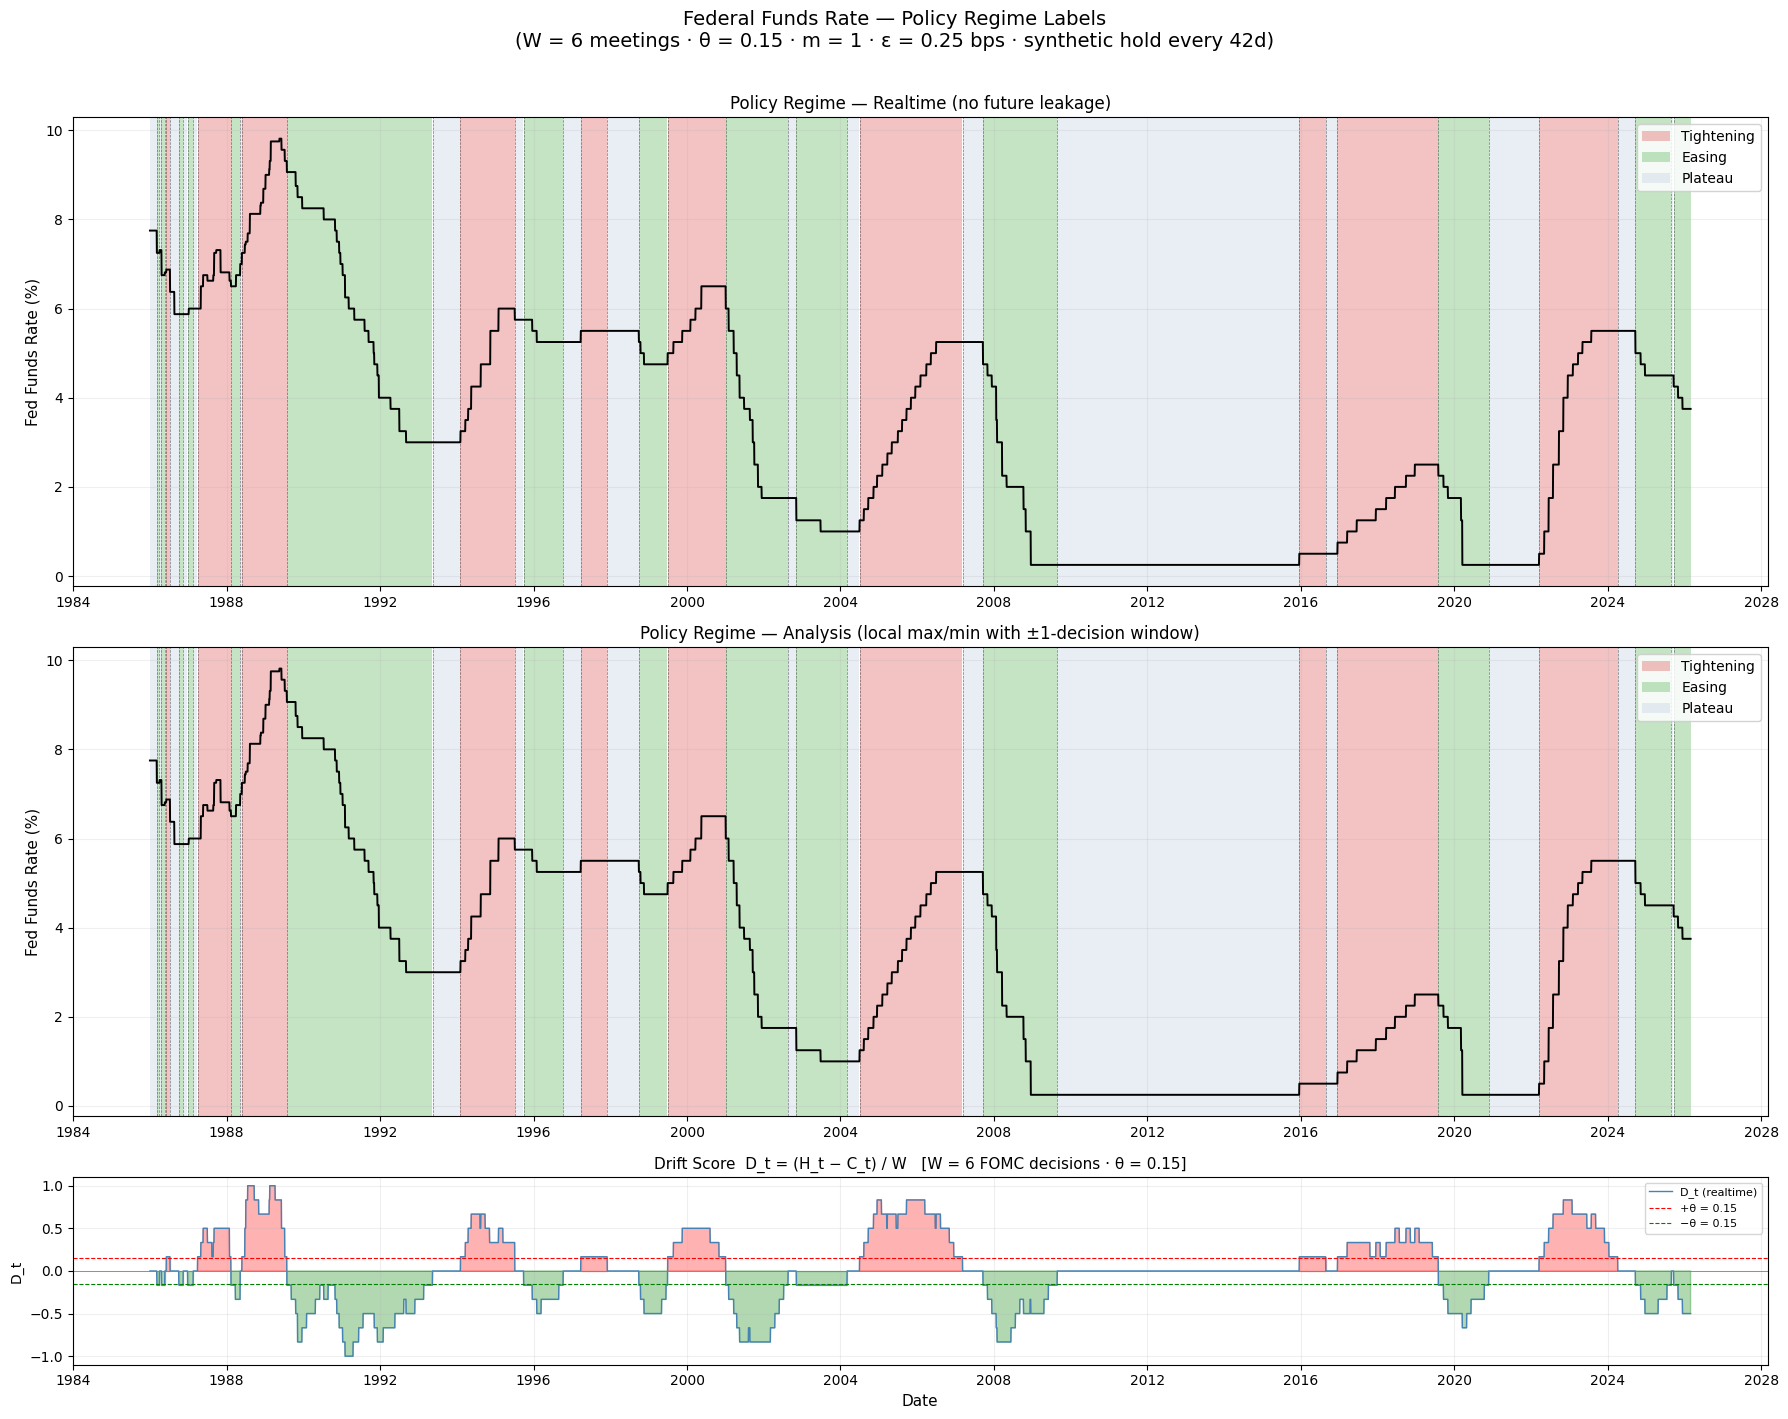

In [109]:
# ── Regime color palette (simplified: 3 states) ───────────────────────────────
REGIME_COLORS_SIMPLE = {
    "Tightening": "#d62728",   # red
    "Easing":     "#2ca02c",   # green
    "Plateau":    "#b0c4de",   # light steel blue
}

def shade_regimes(ax, dates, regimes, colors, alpha=0.28):
    """
    Shade contiguous regime blocks as vertical spans.
    Returns a dict {regime: patch} for building a deduplicated legend.
    """
    dates  = list(dates)
    n      = len(dates)
    legend_handles = {}
    i = 0
    while i < n:
        r = regimes[i]
        j = i
        while j < n and regimes[j] == r:
            j += 1
        color    = colors.get(r, "lightgrey")
        span_end = dates[j - 1] if j < n else dates[-1]
        span     = ax.axvspan(dates[i], span_end, alpha=alpha, color=color, lw=0)
        if r not in legend_handles:
            legend_handles[r] = span
        i = j
    return legend_handles


# ── Main regime plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14),
                          gridspec_kw={"height_ratios": [3, 3, 1.2]})

dates_rt = df_rt["observation_date"].values
dates_an = df_an["observation_date"].values

# ── Panel 1: Realtime regime (regime_simple) ──────────────────────────────────
ax = axes[0]
legend_h = shade_regimes(ax, dates_rt, df_rt["regime_simple"].values, REGIME_COLORS_SIMPLE)
ax.plot(dates_rt, df_rt["fed_rate"], color="black", lw=1.4, zorder=5)

for t in df_rt.index[df_rt["regime_change"]]:
    ax.axvline(dates_rt[t], color="black", lw=0.5, ls="--", alpha=0.5)

ax.set_ylabel("Fed Funds Rate (%)", fontsize=11)
ax.set_title("Policy Regime — Realtime (no future leakage)", fontsize=12)
ordered_labels = [k for k in ["Tightening", "Easing", "Plateau"] if k in legend_h]
ax.legend([legend_h[k] for k in ordered_labels], ordered_labels,
          loc="upper right", fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Panel 2: Analysis regime (regime_simple) ──────────────────────────────────
ax = axes[1]
legend_h2 = shade_regimes(ax, dates_an, df_an["regime_simple"].values, REGIME_COLORS_SIMPLE)
ax.plot(dates_an, df_an["fed_rate"], color="black", lw=1.4, zorder=5)

for t in df_an.index[df_an["regime_change"]]:
    ax.axvline(dates_an[t], color="black", lw=0.5, ls="--", alpha=0.5)

ax.set_ylabel("Fed Funds Rate (%)", fontsize=11)
ax.set_title(f"Policy Regime — Analysis (local max/min with ±{K}-decision window)", fontsize=12)
ordered_labels2 = [k for k in ["Tightening", "Easing", "Plateau"] if k in legend_h2]
ax.legend([legend_h2[k] for k in ordered_labels2], ordered_labels2,
          loc="upper right", fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Panel 3: Drift score D_t ──────────────────────────────────────────────────
ax = axes[2]
ax.plot(dates_rt, df_rt["D_t"], color="steelblue", lw=1.0, label="D_t (realtime)")
ax.axhline( THETA, color="red",   lw=0.8, ls="--", label=f"+θ = {THETA}")
ax.axhline(-THETA, color="green", lw=0.8, ls="--", label=f"−θ = {THETA}")
ax.axhline(0,      color="grey",  lw=0.6)
ax.fill_between(dates_rt, df_rt["D_t"], 0,
                where=df_rt["D_t"] >  THETA, alpha=0.3, color="red",   label="_")
ax.fill_between(dates_rt, df_rt["D_t"], 0,
                where=df_rt["D_t"] < -THETA, alpha=0.3, color="green", label="_")
ax.set_ylabel("D_t", fontsize=10)
ax.set_xlabel("Date", fontsize=11)
ax.set_title(
    f"Drift Score  D_t = (H_t − C_t) / W   "
    f"[W = {W_MEET} FOMC decisions · θ = {THETA}]",
    fontsize=11
)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(
    "Federal Funds Rate — Policy Regime Labels\n"
    f"(W = {W_MEET} meetings · θ = {THETA} · m = {M} · ε = {EPS} bps"
    f" · synthetic hold every {FOMC_DAYS}d)",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()
